In [1]:
#Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
#Step 2: Load Dataset
# Load dataset
df = pd.read_csv("HousingData.csv")

# Remove quotes from column names
df.columns = df.columns.str.replace('"', '')

# Remove missing values
df = df.dropna()

# Display first 5 rows
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7


In [3]:
#Step 3: Split Features and Target
X = df.drop("MEDV", axis=1)   # Features
y = df["MEDV"]                # Target

print(X.shape, y.shape)

(394, 13) (394,)


In [4]:
#Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
#Step 5: Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
#Step 6: Build Deep Neural Network
model = Sequential()

# Single neuron → behaves like linear regression
model.add(Dense(1, input_shape=(X_train.shape[1],), activation='linear'))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1)                   │              14 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14 (56.00 B)

 Trainable params: 14 (56.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
#Step 7: Train Model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 587.0232 - mae: 22.1199 - val_loss: 527.6804 - val_mae: 21.4314
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 585.0080 - mae: 22.1076 - val_loss: 525.7612 - val_mae: 21.4071
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 582.9194 - mae: 22.0939 - val_loss: 523.9131 - val_mae: 21.3834
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 580.8448 - mae: 22.0776 - val_loss: 522.1876 - val_mae: 21.3605
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 579.0324 - mae: 22.0672 - val_loss: 520.2546 - val_mae: 21.3353
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 577.0097 - mae: 22.0541 - val_loss: 518.4792 - val_mae: 21.3119
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 575.0790 - mae: 22.0381 - val_loss: 516.8137 - val_mae: 21.2895
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 573.1441 - mae: 22.0205 - val_loss: 515.1887 - val_mae: 21.2672
Epoch 9/

In [8]:
#Step 8: Evaluate Model
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 505.2495 - mae: 21.1537 
Test Loss (MSE): 505.2495422363281
Test MAE: 21.153690338134766


In [9]:
#Step 9: Predictions
y_pred = model.predict(X_test)

# Compare actual vs predicted
for i in range(5):
    print(f"Actual: {y_test.iloc[i]:.2f} | Predicted: {y_pred[i][0]:.2f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step 
Actual: 25.00 | Predicted: 3.78
Actual: 18.60 | Predicted: 7.46
Actual: 21.00 | Predicted: 2.41
Actual: 23.50 | Predicted: 8.47
Actual: 17.50 | Predicted: 0.74


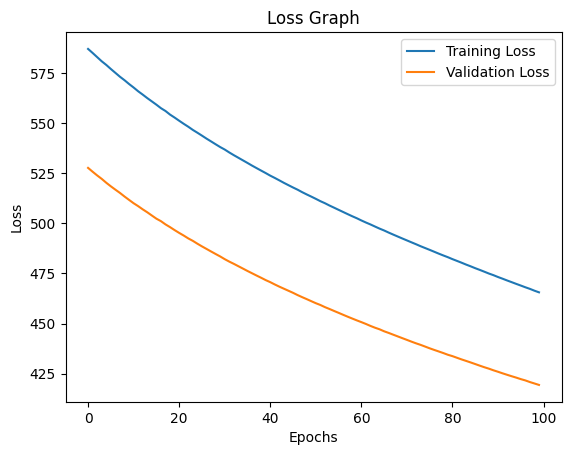

In [10]:
#Step 10: Plot Training Graphs
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.show()